<a href="https://colab.research.google.com/github/Rakib007Nabila/Detection-of-Parkinsons-Using-ML/blob/main/Visualization_EECA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 30.6177 - mae: 4.1040 - val_loss: 25.2250 - val_mae: 2.2157
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19.7148 - mae: 2.2911 - val_loss: 23.3184 - val_mae: 2.3754
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 16.3215 - mae: 2.2998 - val_loss: 21.7499 - val_mae: 2.1934
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 23.4129 - mae: 2.1589 - val_loss: 20.1664 - val_mae: 2.0538
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.2530 - mae: 1.7483 - val_loss: 18.3159 - val_mae: 1.8419
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.2891 - mae: 1.7640 - val_loss: 16.3280 - val_mae: 1.3345
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.5801 - mae: 1.2428 - val_loss: 14.6928 - val_mae: 1.0640
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1778 - mae: 0.9535 - val_loss: 13.4832 - val_mae: 1.0060
Epoch 9/100
175/175 ━━━━━━━━━━━━━━

/tmp/ipython-input-24276105.py:153: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(ch_x_positions, ch_y_positions, c='red', label="Cluster Heads", s=100, edgecolors='black', marker="x")


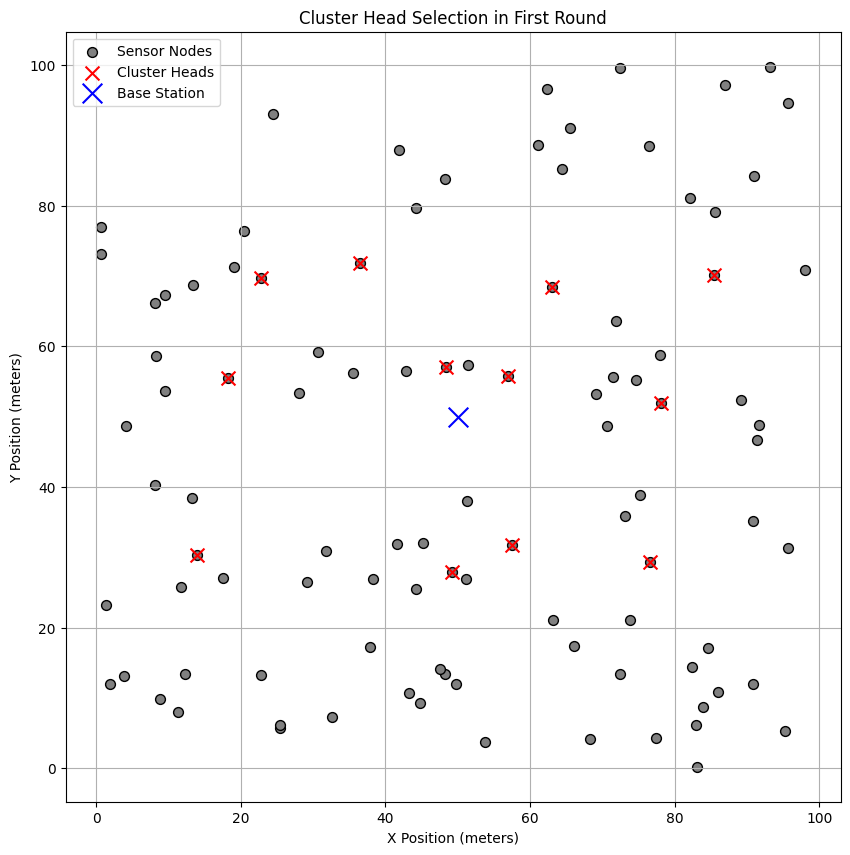

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection
NUM_REGIONS_Y = 3

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================================
# Helper functions
# ================================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# ================================
# Create synthetic dataset & compute target score
# ================================
def make_training_dataset(num_samples=2000, grid_size=GRID_SIZE, seed=32):
    np.random.seed(seed)
    xs = np.random.uniform(0, grid_size, num_samples)
    ys = np.random.uniform(0, grid_size, num_samples)
    energies = np.random.uniform(0.0, INITIAL_ENERGY, num_samples)
    event_counts = np.random.randint(0, 10, num_samples)
    base_x, base_y = base_station
    dist_to_bs = np.sqrt((xs-base_x)**2 + (ys-base_y)**2)

    # compute neighbors (approx) within COMM_RANGE
    neighbors = []
    coords = np.vstack([xs, ys]).T
    for i in range(num_samples):
        dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
        neighbors.append(np.sum(dists <= COMM_RANGE)-1)
    neighbors = np.array(neighbors)

    df = pd.DataFrame({
        "Residual_Energy": energies,
        "Event_Count": event_counts,
        "Distance_to_BS": dist_to_bs,
        "Number_of_Neighbors": neighbors
    })
    return df

def compute_target_score(df, alpha=0.7, beta=0.4):
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

# ================================
# Train the ANN model
# ================================
def train_ann(df_train, epochs=100, batch_size=32):
    X = df_train[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]].values
    y = compute_target_score(df_train)
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.3, random_state=42)

    model = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, scaler

# ================================
# Set up the simulation for Cluster Head Selection (First Round)
# ================================
def run_eemac_ann_ch_visualize():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}

    # Initialize variables to store results
    final_chs_first_round = []

    round_num = 0
    # Only run for the first round
    while round_num < 1 and any(e > 0 for e in node_energy.values()):  # Change here: Only one round
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- CH selection using ANN + region partitioning ---
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for ANN
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])
                X_feat = np.stack([node_energy_arr[eligible], event_counts[eligible], distances_to_bs[eligible], neighbors_count[eligible]], axis=1)
                Xs = ann_scaler.transform(X_feat)
                scores = ann_model.predict(Xs, verbose=0).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)

        final_chs_first_round = final_chs  # store CHs selected in the first round

        # Stop the loop after the first round
        break

    return final_chs_first_round

# ================================
# Visualization of Cluster Heads in the first round
# ================================
def visualize_chs_first_round(chs_first_round):
    # Plot the nodes and the selected Cluster Heads in the first round
    plt.figure(figsize=(10, 10))
    plt.scatter(x_positions, y_positions, label="Sensor Nodes", c='gray', s=50, edgecolors='black')

    # Highlight Cluster Heads with red color
    ch_x_positions = x_positions[chs_first_round]
    ch_y_positions = y_positions[chs_first_round]
    plt.scatter(ch_x_positions, ch_y_positions, c='red', label="Cluster Heads", s=100, edgecolors='black', marker="x")

    # Plot the base station
    plt.scatter(base_station[0], base_station[1], c="blue", s=200, label="Base Station", marker="x")

    # Add labels and grid
    plt.title("Cluster Head Selection in First Round")
    plt.xlabel("X Position (meters)")
    plt.ylabel("Y Position (meters)")
    plt.grid(True)
    plt.legend()
    plt.show()

# ================================
# Run the simulation and visualize
# ================================
# Generate synthetic data for node positions and event counts
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
event_counts = np.random.randint(0, 10, NUM_NODES)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1]) for i in range(NUM_NODES)])
neighbors_count = np.array([np.sum(np.sqrt((x_positions - x_positions[i])**2 + (y_positions - y_positions[i])**2) <= COMM_RANGE)-1 for i in range(NUM_NODES)])

# Prepare the region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# Prepare the ANN model before the simulation
training_df = make_training_dataset(num_samples=2000, seed=42)
ann_model, ann_scaler = train_ann(training_df, epochs=100, batch_size=8)
print("ANN training complete.")

# Run the first round of CH selection and get the selected CHs
chs_first_round = run_eemac_ann_ch_visualize()

# Visualize the selected Cluster Heads
visualize_chs_first_round(chs_first_round)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 19.6881 - mae: 3.0815 - val_loss: 23.5700 - val_mae: 2.1338
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 13.2117 - mae: 2.0103 - val_loss: 19.3911 - val_mae: 1.5875
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.8889 - mae: 1.6533 - val_loss: 18.6461 - val_mae: 1.6463
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.2542 - mae: 1.5986 - val_loss: 18.0118 - val_mae: 1.5967
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.1664 - mae: 1.5284 - val_loss: 17.0298 - val_mae: 1.3344
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3715 - mae: 1.0984 - val_loss: 15.3303 - val_mae: 0.9764
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.8359 - mae: 1.0233 - val_loss: 14.6273 - val_mae: 0.9553
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5058 - mae: 0.9029 - val_loss: 14.1669 - val_mae: 1.0102
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━

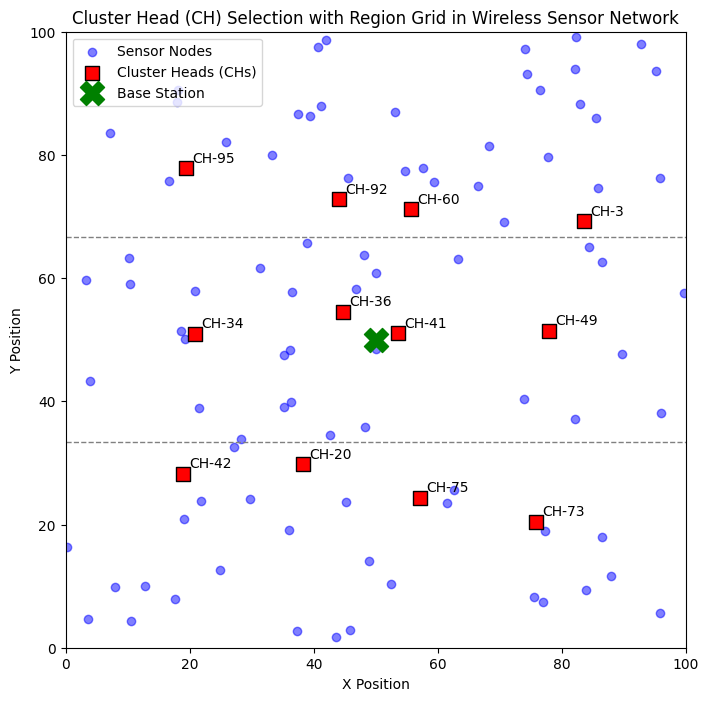

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection
NUM_REGIONS_Y = 3

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================================
# Helper functions
# ================================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# ================================
# Create synthetic dataset & compute target score
# ================================
def make_training_dataset(num_samples=2000, grid_size=GRID_SIZE, seed=32):
    np.random.seed(seed)
    xs = np.random.uniform(0, grid_size, num_samples)
    ys = np.random.uniform(0, grid_size, num_samples)
    energies = np.random.uniform(0.0, INITIAL_ENERGY, num_samples)
    event_counts = np.random.randint(0, 10, num_samples)
    base_x, base_y = base_station
    dist_to_bs = np.sqrt((xs-base_x)**2 + (ys-base_y)**2)

    # compute neighbors (approx) within COMM_RANGE
    neighbors = []
    coords = np.vstack([xs, ys]).T
    for i in range(num_samples):
        dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
        neighbors.append(np.sum(dists <= COMM_RANGE)-1)
    neighbors = np.array(neighbors)

    df = pd.DataFrame({
        "Residual_Energy": energies,
        "Event_Count": event_counts,
        "Distance_to_BS": dist_to_bs,
        "Number_of_Neighbors": neighbors
    })
    return df

def compute_target_score(df, alpha=0.7, beta=0.7):
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

# ================================
# Train the ANN model
# ================================
def train_ann(df_train, epochs=100, batch_size=32):
    X = df_train[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]].values
    y = compute_target_score(df_train)
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.3, random_state=42)

    model = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, scaler

# ================================
# Set up the simulation for Cluster Head Selection (First Round)
# ================================
def run_eemac_ann_ch_visualize():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}

    # Initialize variables to store results
    final_chs_first_round = []

    round_num = 0
    # Only run for the first round
    while round_num < 1 and any(e > 0 for e in node_energy.values()):  # Change here: Only one round
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- CH selection using ANN + region partitioning ---
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for ANN
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])
                X_feat = np.stack([node_energy_arr[eligible], event_counts[eligible], distances_to_bs[eligible], neighbors_count[eligible]], axis=1)
                Xs = ann_scaler.transform(X_feat)
                scores = ann_model.predict(Xs, verbose=0).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)

        final_chs_first_round = final_chs  # store CHs selected in the first round

        # Stop the loop after the first round
        break

    return final_chs_first_round

# ================================
# Visualization of Cluster Heads in the first round
# ================================
def visualize_chs_first_round(chs_first_round):
    # Define the number of regions (should match your CH selection logic)
    region_width = GRID_SIZE / NUM_REGIONS_X
    region_height = GRID_SIZE / NUM_REGIONS_Y

    # Plot all sensor nodes
    plt.figure(figsize=(8, 8))
    plt.scatter(x_positions, y_positions, c='blue', label="Sensor Nodes", alpha=0.5)

    # Plot Cluster Heads (CHs) in red
    ch_x_positions = x_positions[chs_first_round]
    ch_y_positions = y_positions[chs_first_round]
    plt.scatter(ch_x_positions, ch_y_positions, c='red', label="Cluster Heads (CHs)",
                marker="s", edgecolors='black', s=100)

    # Mark Base Station (center of the grid)
    plt.scatter(base_station[0], base_station[1], c="green", s=300, marker="X", label="Base Station")

    # Annotate each CH with its Node_ID
    for i, ch in enumerate(chs_first_round):
        plt.text(x_positions[ch] + 1, y_positions[ch] + 1, f"CH-{int(ch)}", fontsize=10, color='black')



    # Draw horizontal grid lines (region boundaries)
    for j in range(1, NUM_REGIONS_Y):
        plt.axhline(y=j * region_height, color='gray', linestyle='--', linewidth=1)

    # Add axis labels and title
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title("Cluster Head (CH) Selection with Region Grid in Wireless Sensor Network")
    plt.legend()
    #plt.grid(True)
    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)

    # Show the plot
    plt.show()

# ================================
# Run the simulation and visualize
# ================================
# Generate synthetic data for node positions and event counts
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
event_counts = np.random.randint(0, 10, NUM_NODES)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1]) for i in range(NUM_NODES)])
neighbors_count = np.array([np.sum(np.sqrt((x_positions - x_positions[i])**2 + (y_positions - y_positions[i])**2) <= COMM_RANGE)-1 for i in range(NUM_NODES)])

# Prepare the region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# Prepare the ANN model before the simulation
training_df = make_training_dataset(num_samples=2000, seed=42)
ann_model, ann_scaler = train_ann(training_df, epochs=100, batch_size=8)
print("ANN training complete.")

# Run the first round of CH selection and get the selected CHs
chs_first_round = run_eemac_ann_ch_visualize()

# Visualize the selected Cluster Heads
visualize_chs_first_round(chs_first_round)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 18.4624 - mae: 3.0899 - val_loss: 21.5301 - val_mae: 1.7369
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.8800 - mae: 1.6339 - val_loss: 18.4856 - val_mae: 1.6067
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5712 - mae: 1.3965 - val_loss: 17.2768 - val_mae: 1.4694
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.9189 - mae: 1.2931 - val_loss: 15.7856 - val_mae: 1.0810
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.7365 - mae: 1.0117 - val_loss: 14.7591 - val_mae: 0.9621
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0651 - mae: 0.9781 - val_loss: 14.2112 - val_mae: 0.9860
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.2624 - mae: 0.9913 - val_loss: 13.7847 - val_mae: 0.9109
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.7581 - mae: 0.8258 - val_loss: 13.3041 - val_mae: 0.9258
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

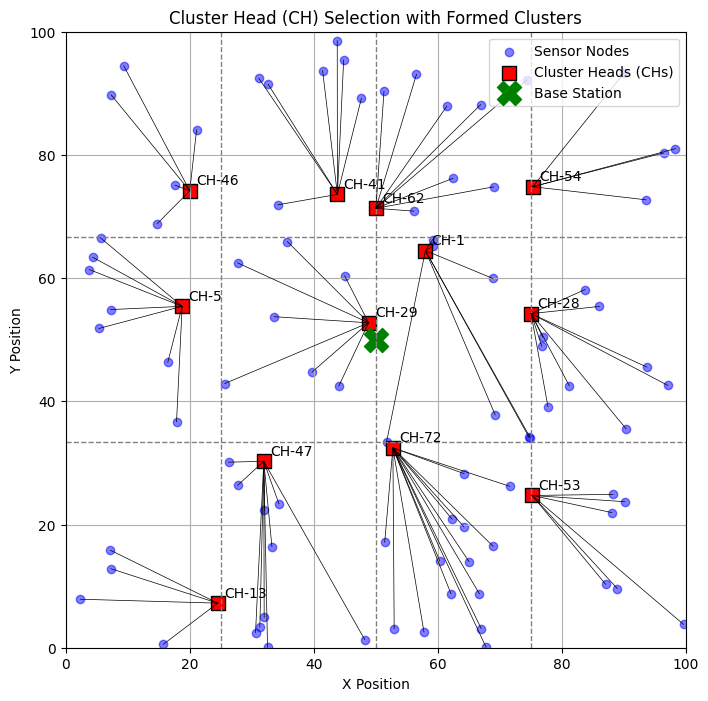

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection
NUM_REGIONS_Y = 3

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================================
# Helper functions
# ================================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# ================================
# Create synthetic dataset & compute target score
# ================================
def make_training_dataset(num_samples=2000, grid_size=GRID_SIZE, seed=32):
    np.random.seed(seed)
    xs = np.random.uniform(0, grid_size, num_samples)
    ys = np.random.uniform(0, grid_size, num_samples)
    energies = np.random.uniform(0.0, INITIAL_ENERGY, num_samples)
    event_counts = np.random.randint(0, 10, num_samples)
    base_x, base_y = base_station
    dist_to_bs = np.sqrt((xs-base_x)**2 + (ys-base_y)**2)

    # compute neighbors (approx) within COMM_RANGE
    neighbors = []
    coords = np.vstack([xs, ys]).T
    for i in range(num_samples):
        dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
        neighbors.append(np.sum(dists <= COMM_RANGE)-1)
    neighbors = np.array(neighbors)

    df = pd.DataFrame({
        "Residual_Energy": energies,
        "Event_Count": event_counts,
        "Distance_to_BS": dist_to_bs,
        "Number_of_Neighbors": neighbors
    })
    return df

def compute_target_score(df, alpha=0.7, beta=0.7):
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

# ================================
# Train the ANN model
# ================================
def train_ann(df_train, epochs=100, batch_size=32):
    X = df_train[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]].values
    y = compute_target_score(df_train)
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.3, random_state=42)

    model = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, scaler

# ================================
# Set up the simulation for Cluster Head Selection (First Round)
# ================================
def run_eemac_ann_ch_visualize():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}

    # Initialize variables to store results
    final_chs_first_round = []

    round_num = 0
    # Only run for the first round
    while round_num < 1 and any(e > 0 for e in node_energy.values()):  # Change here: Only one round
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- CH selection using ANN + region partitioning ---
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for ANN
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])
                X_feat = np.stack([node_energy_arr[eligible], event_counts[eligible], distances_to_bs[eligible], neighbors_count[eligible]], axis=1)
                Xs = ann_scaler.transform(X_feat)
                scores = ann_model.predict(Xs, verbose=0).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)

        final_chs_first_round = final_chs  # store CHs selected in the first round

        # Stop the loop after the first round
        break

    return final_chs_first_round

# ================================
# Visualization of Cluster Heads and Formed Clusters in the first round
# ================================
def visualize_clusters(chs_first_round):
    # Define the number of regions (should match your CH selection logic)
    region_width = GRID_SIZE / NUM_REGIONS_X
    region_height = GRID_SIZE / NUM_REGIONS_Y

    # Plot all sensor nodes
    plt.figure(figsize=(8, 8))
    plt.scatter(x_positions, y_positions, c='blue', label="Sensor Nodes", alpha=0.5)

    # Plot Cluster Heads (CHs) in red
    ch_x_positions = x_positions[chs_first_round]
    ch_y_positions = y_positions[chs_first_round]
    plt.scatter(ch_x_positions, ch_y_positions, c='red', label="Cluster Heads (CHs)",
                marker="s", edgecolors='black', s=100)

    # Mark Base Station (center of the grid)
    plt.scatter(base_station[0], base_station[1], c="green", s=300, marker="X", label="Base Station")

    # Annotate each CH with its Node_ID
    for i, ch in enumerate(chs_first_round):
        plt.text(x_positions[ch] + 1, y_positions[ch] + 1, f"CH-{int(ch)}", fontsize=10, color='black')

    # Draw vertical grid lines (region boundaries)
    for i in range(1, NUM_REGIONS_X):
        plt.axvline(x=i * region_width, color='gray', linestyle='--', linewidth=1)

    # Draw horizontal grid lines (region boundaries)
    for j in range(1, NUM_REGIONS_Y):
        plt.axhline(y=j * region_height, color='gray', linestyle='--', linewidth=1)

    # Connect nodes to their respective CHs (forming clusters)
    for ch in chs_first_round:
        assigned_nodes = [n for n in range(NUM_NODES) if assign_region(x_positions[n], y_positions[n], region_width, region_height) == assign_region(x_positions[ch], y_positions[ch], region_width, region_height)]
        for node in assigned_nodes:
            if node != ch:
                plt.plot([x_positions[ch], x_positions[node]], [y_positions[ch], y_positions[node]], c='black', linestyle='-', linewidth=0.5)

    # Add axis labels and title
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title("Cluster Head (CH) Selection with Formed Clusters")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)

    # Show the plot
    plt.show()

# ================================
# Run the simulation and visualize
# ================================
# Generate synthetic data for node positions and event counts
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
event_counts = np.random.randint(0, 10, NUM_NODES)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1]) for i in range(NUM_NODES)])
neighbors_count = np.array([np.sum(np.sqrt((x_positions - x_positions[i])**2 + (y_positions - y_positions[i])**2) <= COMM_RANGE)-1 for i in range(NUM_NODES)])

# Prepare the region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# Prepare the ANN model before the simulation
training_df = make_training_dataset(num_samples=2000, seed=42)
ann_model, ann_scaler = train_ann(training_df, epochs=100, batch_size=8)
print("ANN training complete.")

# Run the first round of CH selection and get the selected CHs
chs_first_round = run_eemac_ann_ch_visualize()

# Visualize the selected Cluster Heads and Formed Clusters
visualize_clusters(chs_first_round)
